In [1]:
import sys
from PIL import Image
import os
import numpy as np

In [2]:
sys.path.append(os.path.join(os.getcwd(), 'histocartography'))
from histocartography.preprocessing import NucleiExtractor, DeepFeatureExtractor, KNNGraphBuilder
from histocartography.visualization import OverlayGraphVisualization, InstanceImageVisualization

/data/mn27889/miniconda3/envs/pbt-histo/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
nuclei_detector = NucleiExtractor()
feature_extractor = DeepFeatureExtractor(architecture='resnet34', patch_size=72)
knn_graph_builder = KNNGraphBuilder(k=5, thresh=50, add_loc_feats=True)

File already downloaded.


/data/mn27889/pbt-histocartography/histocartography/histocartography/preprocessing/nuclei_extraction.py:88: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.model = torch.

In [4]:
image = np.array(Image.open('histocartography/docs/_static/283_dcis_4.png'))
nuclei_map, _ = nuclei_detector.process(image)
features = feature_extractor.process(image, nuclei_map)
cell_graph = knn_graph_builder.process(nuclei_map, features)

Patch-level nuclei detection:   0%|          | 0/2 [00:00<?, ?it/s]/data/mn27889/pbt-histocartography/histocartography/histocartography/ml/models/hovernet.py:233: UserWarning: `nn.functional.upsample` is deprecated. Use `nn.functional.interpolate` instead.
  x = F.upsample(x, scale_factor=2, mode='nearest')
Patch-level nuclei detection: 100%|██████████| 2/2 [00:00<00:00,  3.25it/s]
/data/mn27889/miniconda3/envs/pbt-histo/lib/python3.9/site-packages/numpy/_core/fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/data/mn27889/miniconda3/envs/pbt-histo/lib/python3.9/site-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/data/mn27889/miniconda3/envs/pbt-histo/lib/python3.9/site-packages/dgl/heterograph.py:92: DGLWarning: Recommend creating graphs by `dgl.graph(data)` instead of `dgl.DGLGraph(data)`.
  dgl_warning(


In [7]:
visualizer = OverlayGraphVisualization(instance_visualizer=InstanceImageVisualization(instance_style="filled+outline"))
viz_cg = visualizer.process(canvas=image, graph=cell_graph, instance_map=nuclei_map)

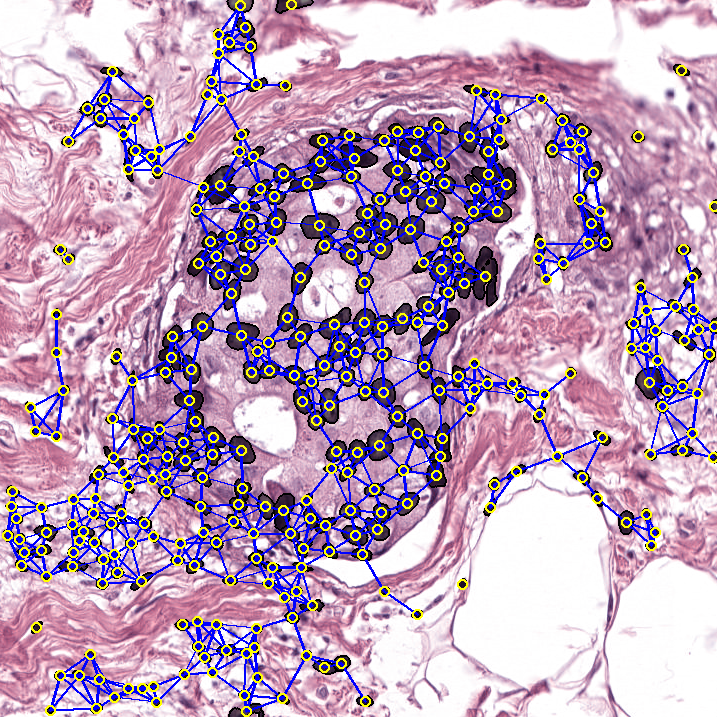

In [9]:
viz_cg